# ITEC623 – Deep Learning and Emerging Topics in Artificial Intelligence

## Lab 3: Data Pipelines, Pre-processing, and Reproducible AI Workflows

**Student Name:** Emmanuel Orunta  
**Student ID:** S00403657

### Lab Overview

This lab focuses on preparing image data for deep-learning models. The CIFAR-10
dataset is loaded and inspected, followed by image normalisation, reproducible
data shuffling and construction of a TensorFlow Dataset pipeline. The lab also
looks at class distributions, possible bias, and how the same pipeline ideas
can be applied to cloud-based machine-learning workflows.



In [1]:
# Importing Libraries

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.3


In [2]:
# Reproducibility setup

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python random seed:", SEED)
print("NumPy random seed:", SEED)
print("TensorFlow random seed:", SEED)

Python random seed: 42
NumPy random seed: 42
TensorFlow random seed: 42


## TASK 1 — Dataset Loading and Inspection

In [3]:
# Load CIFAR-10

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 934s 5us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


In [4]:
# CIFAR-10 class names
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("\nClasses:")

for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

Number of classes: 10

Classes:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


In [5]:
# Display example labels

print("First 10 numerical labels:")
print(y_train[:10].flatten())

print("\nFirst 10 class names:")

for label in y_train[:10].flatten():
    print(class_names[label])

First 10 numerical labels:
[6 9 9 4 1 1 2 7 8 3]

First 10 class names:
frog
truck
truck
deer
automobile
automobile
bird
horse
ship
cat


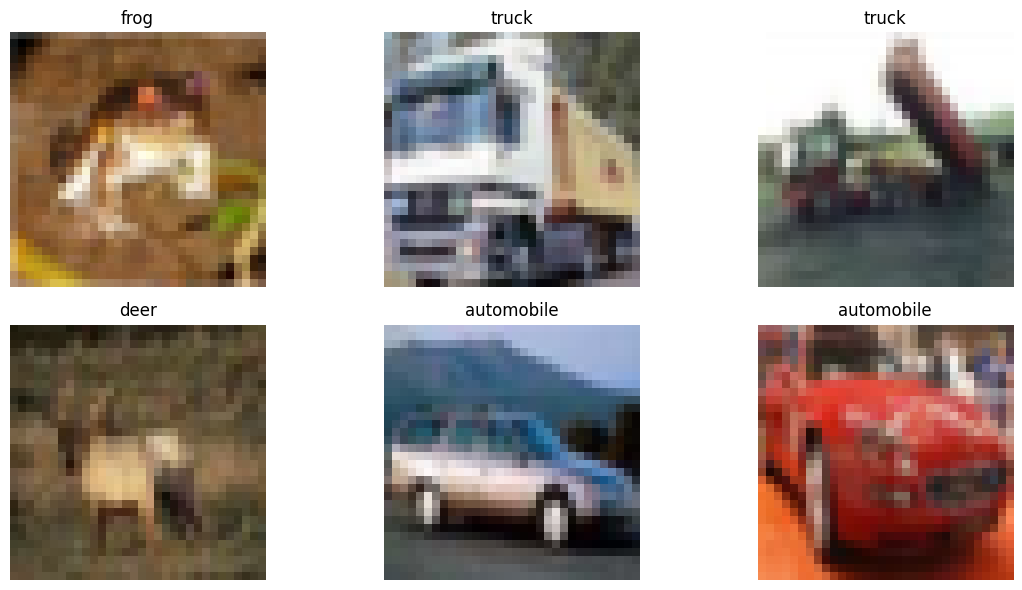

In [6]:
# Visualizing six CIFAR-10 samples

plt.figure(figsize=(12, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    plt.imshow(X_train[i])

    label = y_train[i][0]
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

I used the CIFAR-10 dataset, which contains 60,000 colour images across ten classes. Each image is 32 × 32 pixels and has three colour channels. The dataset provides 50,000 training images and 10,000 test images. The labels represent categories such as airplane, automobile, bird, cat, dog and truck. I also displayed six sample images with their class names to get a basic understanding of the data. The samples show that images within the same class can look quite different, which makes the dataset suitable for testing image-based neural networks.

## TASK 2 — Image Normalisation and Tensor Preparation

In [7]:
# Inspecting raw pixel values

print("Raw data type:", X_train.dtype)
print("Raw minimum pixel value:", X_train.min())
print("Raw maximum pixel value:", X_train.max())
print("Example raw pixel values:")
print(X_train[0, 0, 0])

Raw data type: uint8
Raw minimum pixel value: 0
Raw maximum pixel value: 255
Example raw pixel values:
[59 62 63]


In [8]:
# Convert image data to float32 and normalise to [0, 1]

X_train_normalised = X_train.astype("float32") / 255.0
X_test_normalised = X_test.astype("float32") / 255.0

print("Normalised training data type:", X_train_normalised.dtype)

print("Normalised minimum pixel value:",
      X_train_normalised.min())

print("Normalised maximum pixel value:",
      X_train_normalised.max())

Normalised training data type: float32
Normalised minimum pixel value: 0.0
Normalised maximum pixel value: 1.0


In [9]:
# Before vs after normalisation

print("BEFORE NORMALISATION")
print("--------------------")
print("Data type:", X_train.dtype)
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("\nAFTER NORMALISATION")
print("-------------------")
print("Data type:", X_train_normalised.dtype)
print("Minimum:", X_train_normalised.min())
print("Maximum:", X_train_normalised.max())

BEFORE NORMALISATION
--------------------
Data type: uint8
Minimum: 0
Maximum: 255

AFTER NORMALISATION
-------------------
Data type: float32
Minimum: 0.0
Maximum: 1.0


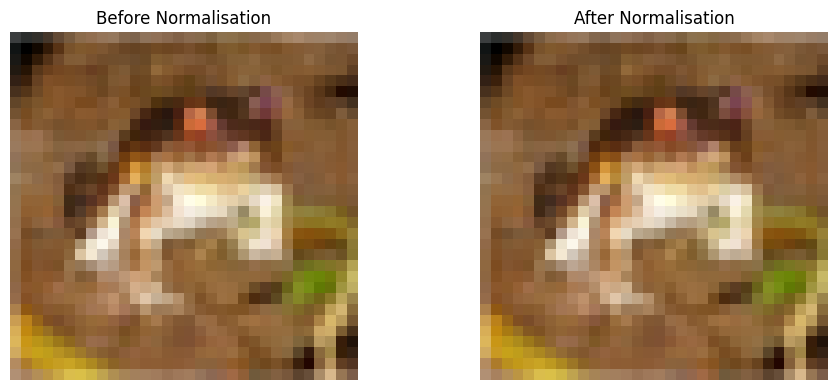

In [10]:
# Visual comparison

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_train[0])
plt.title("Before Normalisation")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_train_normalised[0])
plt.title("After Normalisation")
plt.axis("off")

plt.tight_layout()
plt.show()

The original CIFAR-10 images contain integer pixel values between 0 and 255. I converted the images to float32 and divided each pixel value by 255, resulting in values between 0 and 1. This makes the data more suitable for neural-network training because the inputs are on a smaller and consistent numerical scale. Before scaling, the data type was uint8 with a maximum value of 255. After scaling, the data type became float32 and the maximum value became 1.0. The visual appearance of the images remained effectively unchanged.

## TASK 3 — Reproducibility and Random Seed Control

In [11]:
# Demonstrate reproducible shuffling

# First shuffle
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

indices = np.arange(20)

shuffled_1 = np.random.permutation(indices)

print("First shuffled order:")
print(shuffled_1)

# Reset NumPy seed and shuffle again
np.random.seed(SEED)

shuffled_2 = np.random.permutation(indices)

print("\nSecond shuffled order:")
print(shuffled_2)

# Compare the two results
same_order = np.array_equal(
    shuffled_1,
    shuffled_2
)

print("\nAre the two shuffled orders identical?", same_order)

First shuffled order:
[ 0 17 15  1  8  5 11  3 18 16 13  2  9 19  4 12  7 10 14  6]

Second shuffled order:
[ 0 17 15  1  8  5 11  3 18 16 13  2  9 19  4 12  7 10 14  6]

Are the two shuffled orders identical? True


In [12]:
# TensorFlow reproducibility check

tf.random.set_seed(SEED)

random_tensor_1 = tf.random.uniform(
    shape=(5,),
    seed=SEED
)

tf.random.set_seed(SEED)

random_tensor_2 = tf.random.uniform(
    shape=(5,),
    seed=SEED
)

print("First TensorFlow result:")
print(random_tensor_1.numpy())

print("\nSecond TensorFlow result:")
print(random_tensor_2.numpy())

print(
    "\nAre they identical?",
    np.array_equal(
        random_tensor_1.numpy(),
        random_tensor_2.numpy()
    )
)

First TensorFlow result:
[0.4163028  0.26858163 0.47968316 0.36457133 0.95471144]

Second TensorFlow result:
[0.4163028  0.26858163 0.47968316 0.36457133 0.95471144]

Are they identical? True


I used the same random seed, 42, for Python, NumPy and TensorFlow. To test reproducibility, I shuffled a set of sample indices and then repeated the operation after resetting the NumPy seed. Both runs produced the same order, showing that the random process could be reproduced under the same conditions. Reproducibility is important because it allows researchers and developers to repeat experiments and check whether changes to a model or pipeline actually affect the results. It is also useful in industry when debugging models or comparing experiments.

## TASK 4 — TensorFlow Dataset API Pipeline

In [13]:
# TASK 4 - TensorFlow Dataset API Pipeline

# Flatten labels from shape (n, 1) to (n,)
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

print("Training images:", X_train.shape)
print("Training labels:", y_train_flat.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test_flat.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


In [14]:
# Create TensorFlow Dataset objects

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train_flat)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test_flat)
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [15]:
# Normalisation function for the pipeline

def normalise_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [16]:
# Build training pipeline

BATCH_SIZE = 64

train_pipeline = (
    train_dataset
    .map(
        normalise_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .shuffle(
        buffer_size=10000,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training pipeline created.")

Training pipeline created.


In [17]:
# Build test pipeline

test_pipeline = (
    test_dataset
    .map(
        normalise_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Test pipeline created.")

Test pipeline created.


In [18]:
# Inspect one training batch

for batch_images, batch_labels in train_pipeline.take(1):

    print("Batch image shape:", batch_images.shape)
    print("Batch label shape:", batch_labels.shape)

    print("Batch data type:", batch_images.dtype)

    print("Batch minimum value:", tf.reduce_min(batch_images).numpy())
    print("Batch maximum value:", tf.reduce_max(batch_images).numpy())

Batch image shape: (64, 32, 32, 3)
Batch label shape: (64,)
Batch data type: <dtype: 'float32'>
Batch minimum value: 0.0
Batch maximum value: 1.0


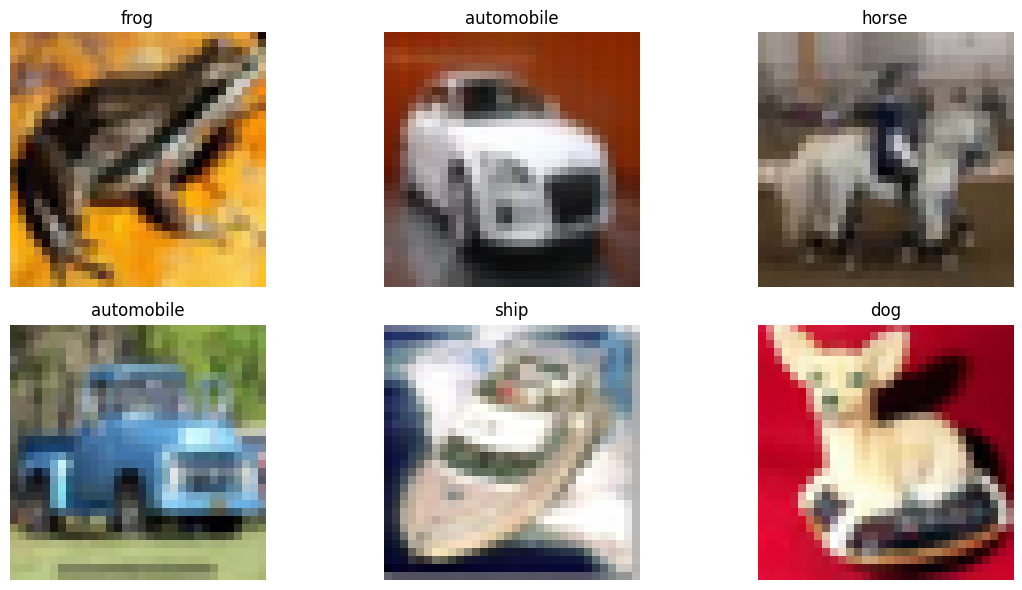

In [19]:
# Visualize images coming directly from the tf.data pipeline

for batch_images, batch_labels in train_pipeline.take(1):

    plt.figure(figsize=(12, 6))

    for i in range(6):
        plt.subplot(2, 3, i + 1)

        plt.imshow(batch_images[i].numpy())

        label = batch_labels[i].numpy()
        plt.title(class_names[label])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Pipeline Workflow

The data pipeline follows the sequence:

Raw images  
→ map / normalise  
→ shuffle  
→ batch  
→ prefetch  
→ model

The training data is shuffled so that the model does not repeatedly see
examples in the same order. Batching groups samples together for efficient
training, while prefetching prepares future batches while the current batch
is being processed.

The tf.data pipeline processes the images through a sequence of mapping, shuffling, batching and prefetching operations. Normalisation is performed during the mapping stage, so the raw images do not need to be stored separately as another processed dataset. Shuffling helps provide better variation between training batches, while batching allows the model to process multiple images efficiently. Prefetching allows data preparation to overlap with model computation, which can reduce waiting time during training. This approach is also useful for cloud training because data can be processed in a streaming pipeline instead of requiring the entire dataset to be loaded into memory at once.

## TASK 5 — Distribution and Bias Analysis

In [20]:
# Class Distribution

class_counts = np.bincount(
    y_train_flat,
    minlength=num_classes
)

distribution_table = pd.DataFrame({
    "Class": class_names,
    "Class ID": range(num_classes),
    "Number of Images": class_counts
})

distribution_table

,Class,Class ID,Number of Images
0,airplane,0,5000
1,automobile,1,5000
2,bird,2,5000
3,cat,3,5000
4,deer,4,5000
5,dog,5,5000
6,frog,6,5000
7,horse,7,5000
8,ship,8,5000
9,truck,9,5000


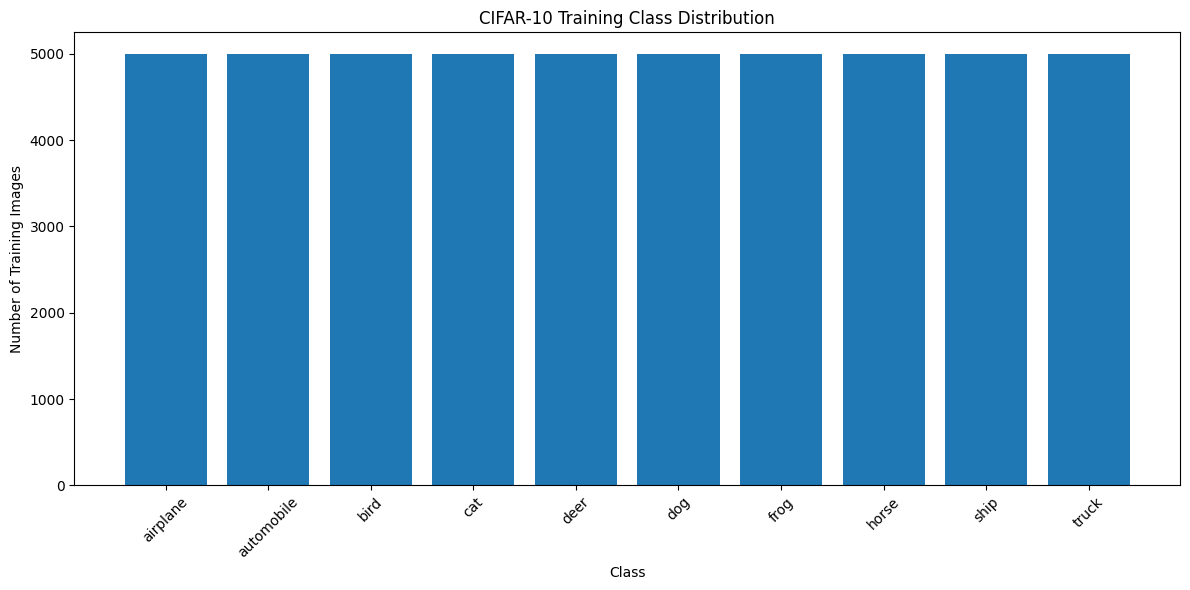

In [21]:
# Plot class frequency distribution

plt.figure(figsize=(12, 6))

plt.bar(
    class_names,
    class_counts
)

plt.xlabel("Class")
plt.ylabel("Number of Training Images")
plt.title("CIFAR-10 Training Class Distribution")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# Calculate class percentages

class_percentages = (
    class_counts / class_counts.sum()
) * 100

distribution_table["Percentage"] = class_percentages

distribution_table

,Class,Class ID,Number of Images,Percentage
0,airplane,0,5000,10.0
1,automobile,1,5000,10.0
2,bird,2,5000,10.0
3,cat,3,5000,10.0
4,deer,4,5000,10.0
5,dog,5,5000,10.0
6,frog,6,5000,10.0
7,horse,7,5000,10.0
8,ship,8,5000,10.0
9,truck,9,5000,10.0


In [23]:
# Basic imbalance analysis

minimum_count = class_counts.min()
maximum_count = class_counts.max()

imbalance_difference = maximum_count - minimum_count

print("Minimum class count:", minimum_count)
print("Maximum class count:", maximum_count)
print("Difference:", imbalance_difference)

if minimum_count == maximum_count:
    print("\nThe training classes are perfectly balanced.")
else:
    print("\nThere is some difference between class frequencies.")

Minimum class count: 5000
Maximum class count: 5000
Difference: 0

The training classes are perfectly balanced.


The class-frequency plot shows that the CIFAR-10 training set is well balanced, with approximately the same number of images in each of the ten classes. This means there is no obvious class-frequency imbalance that would cause the model to favour one class simply because it appears much more often. However, balanced class counts do not completely remove the possibility of bias. Some classes may be visually harder to recognise, and the images may not represent all real-world variations equally. For a neural network, these differences could lead to weaker performance for certain types of images. In deployment, this matters because apparently balanced training data can still produce uneven performance across different situations.

## TASK 6 — Cloud-Ready Data Engineering Reflection

Data pipelines become increasingly important when machine-learning datasets grow beyond the capacity of a single computer. Instead of loading everything into memory, a cloud workflow can stream data in smaller batches and process it as required. This approach can make training more scalable and reduce memory limitations. The same idea can be applied to Azure ML pipelines, where data preparation and model training can be organised as repeatable workflow steps. Another important issue is preprocessing consistency. If training data is normalised in one way but production data is processed differently, model performance can change after deployment. Keeping preprocessing inside a defined pipeline makes the process easier to reproduce and maintain. This is especially important when models are retrained regularly using new data.